In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
matches = pd.read_csv(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\data\matches_cleaned.csv")

deliveries = pd.read_csv(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\data\deliveries_cleaned.csv")

print("✅ Data loaded successfully!")
print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

✅ Data loaded successfully!
Matches: (1095, 20)
Deliveries: (260920, 18)


C:\Users\Shruti Kumari Pandey\AppData\Local\Temp\ipykernel_14496\4417255.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.values, y=team_wins.index, palette='Reds_r')


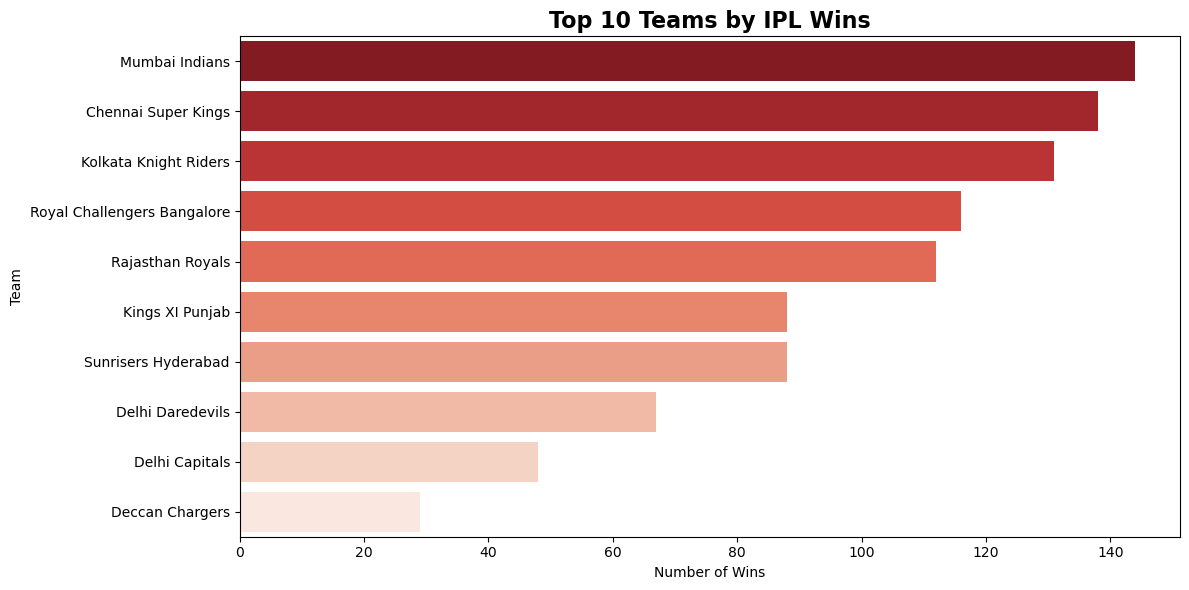

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


In [2]:
# Step 16: Top teams by wins
team_wins = matches['winner'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=team_wins.values, y=team_wins.index, palette='Reds_r')

plt.title('Top 10 Teams by IPL Wins', fontsize=16, fontweight='bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\top_teams_wins.png")
plt.show()

print(team_wins)

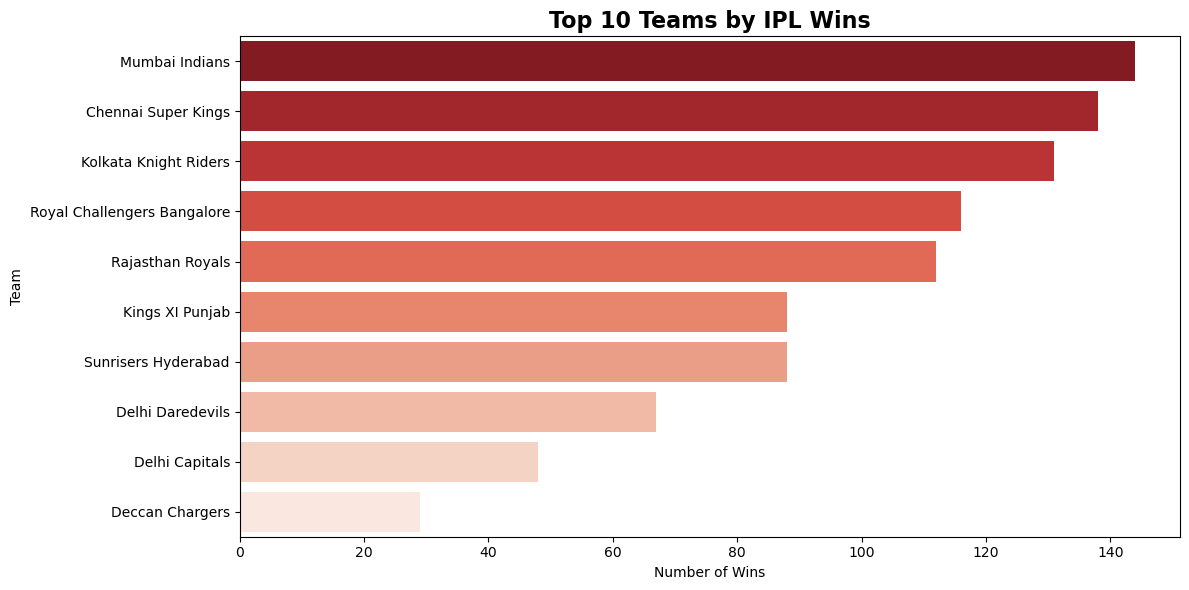

In [3]:
# Step 16: Top teams by wins (fixed)
team_wins = matches['winner'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=team_wins.values, y=team_wins.index, 
            hue=team_wins.index, palette='Reds_r', legend=False)

plt.title('Top 10 Teams by IPL Wins', fontsize=16, fontweight='bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\top_teams_wins.png")
plt.show()

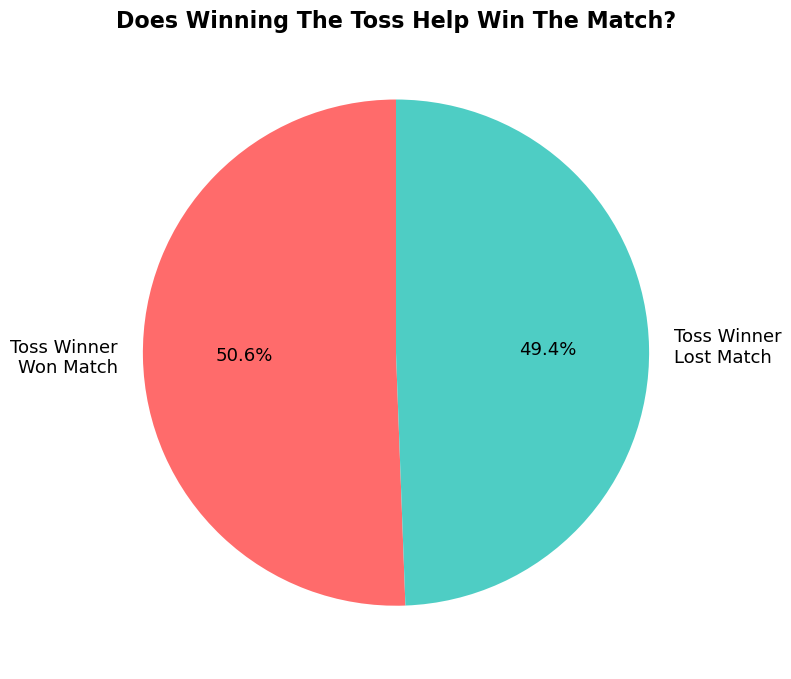

Toss winner won the match: 554 times (50.6%)
Toss winner lost the match: 541 times (49.4%)


In [4]:
# Step 17: Does winning toss help win the match?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

toss_impact = matches['toss_match_winner'].value_counts()
labels = ['Toss Winner\nWon Match', 'Toss Winner\nLost Match']

plt.figure(figsize=(8,8))
plt.pie(toss_impact.values, labels=labels, autopct='%1.1f%%',
        colors=['#FF6B6B', '#4ECDC4'], startangle=90,
        textprops={'fontsize': 13})

plt.title('Does Winning The Toss Help Win The Match?', 
          fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\toss_impact.png")
plt.show()

# Print exact numbers
total = len(matches)
won = toss_impact[True]
print(f"Toss winner won the match: {won} times ({won/total*100:.1f}%)")
print(f"Toss winner lost the match: {total-won} times ({(total-won)/total*100:.1f}%)")

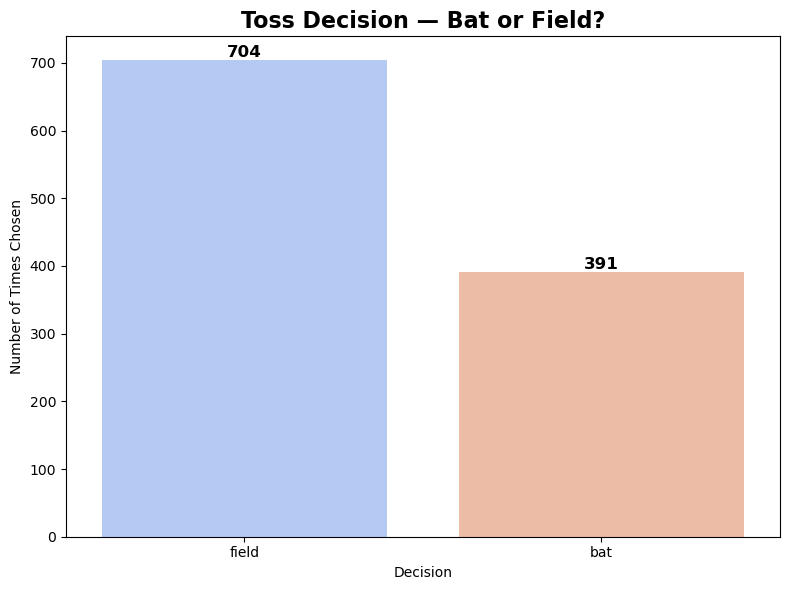

toss_decision
field    704
bat      391
Name: count, dtype: int64


In [5]:
# Step 18: Toss decision preference
toss_decision = matches['toss_decision'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=toss_decision.index, y=toss_decision.values,
            hue=toss_decision.index, palette='coolwarm', legend=False)

plt.title('Toss Decision — Bat or Field?', fontsize=16, fontweight='bold')
plt.xlabel('Decision')
plt.ylabel('Number of Times Chosen')

for i, v in enumerate(toss_decision.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\toss_decision.png")
plt.show()

print(toss_decision)

In [6]:
# Step 19: Matches per season
season_matches = matches.groupby('season').size().reset_index(name='matches')

plt.figure(figsize=(14,6))
sns.lineplot(data=season_matches, x='season', y='matches',
             marker='o', color='#FF6B6B', linewidth=2.5, markersize=8)

plt.title('Number of Matches Per IPL Season', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)

for i, row in season_matches.iterrows():
    plt.text(i, row['matches']+0.5, str(row['matches']), 
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\matches_per_season.png")
plt.show()

C:\Users\Shruti Kumari Pandey\AppData\Local\Temp\ipykernel_14496\566050356.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [9]:
# Step 19: Matches per season (fixed)
season_matches = matches.groupby('season').size().reset_index(name='matches')

plt.figure(figsize=(16,7))
sns.lineplot(data=season_matches, x='season', y='matches',
             marker='o', color='#FF6B6B', linewidth=2.5, markersize=8)

plt.title('Number of Matches Per IPL Season', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45, ha='right')

for i, row in season_matches.iterrows():
    plt.text(i, row['matches']+0.5, str(row['matches']), 
             ha='center', fontsize=9, fontweight='bold')

plt.subplots_adjust(bottom=0.2)
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\matches_per_season.png")
plt.show()

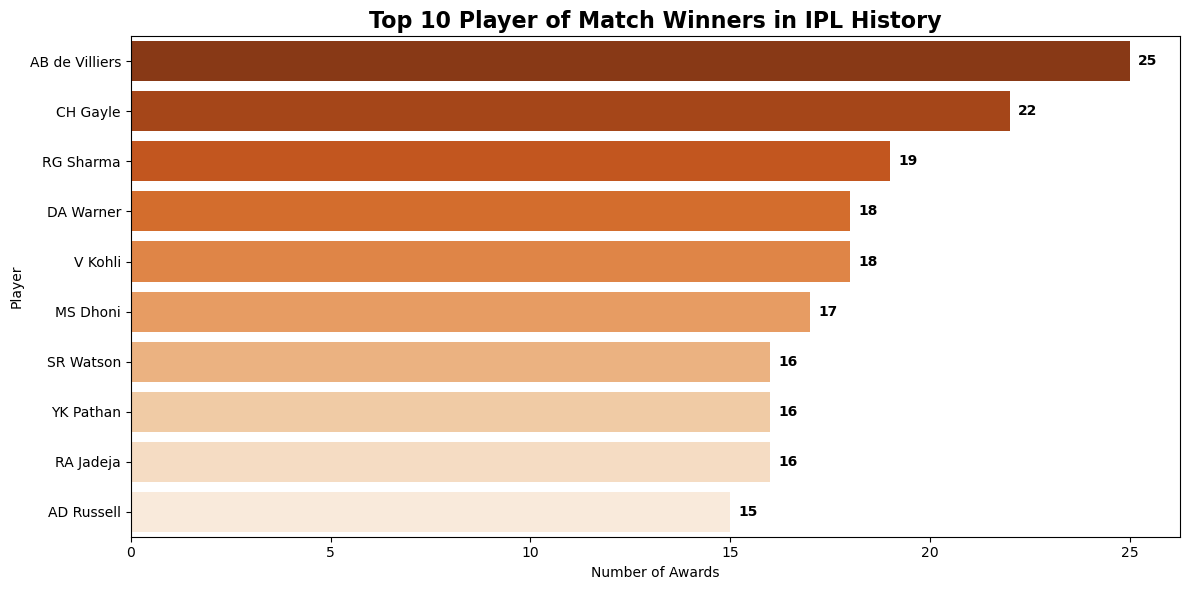

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
AD Russell        15
Name: count, dtype: int64


In [10]:
# Step 20: Top Player of Match winners
top_players = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_players.values, y=top_players.index,
            hue=top_players.index, palette='Oranges_r', legend=False)

plt.title('Top 10 Player of Match Winners in IPL History', 
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Awards')
plt.ylabel('Player')

for i, v in enumerate(top_players.values):
    plt.text(v + 0.2, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\top_players.png")
plt.show()

print(top_players)

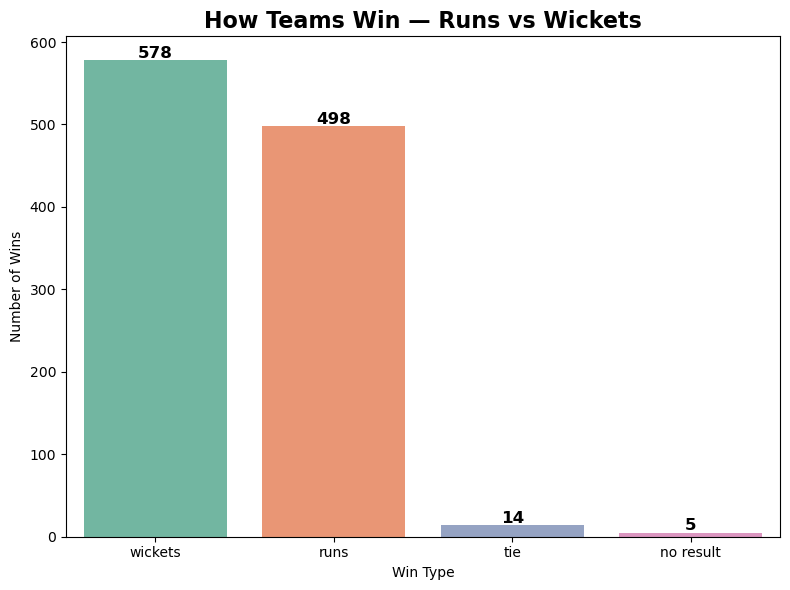

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64


In [11]:
# Step 21: Batting first vs chasing wins
win_type = matches['result'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=win_type.index, y=win_type.values,
            hue=win_type.index, palette='Set2', legend=False)

plt.title('How Teams Win — Runs vs Wickets', 
          fontsize=16, fontweight='bold')
plt.xlabel('Win Type')
plt.ylabel('Number of Wins')

for i, v in enumerate(win_type.values):
    plt.text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\win_type.png")
plt.show()

print(win_type)

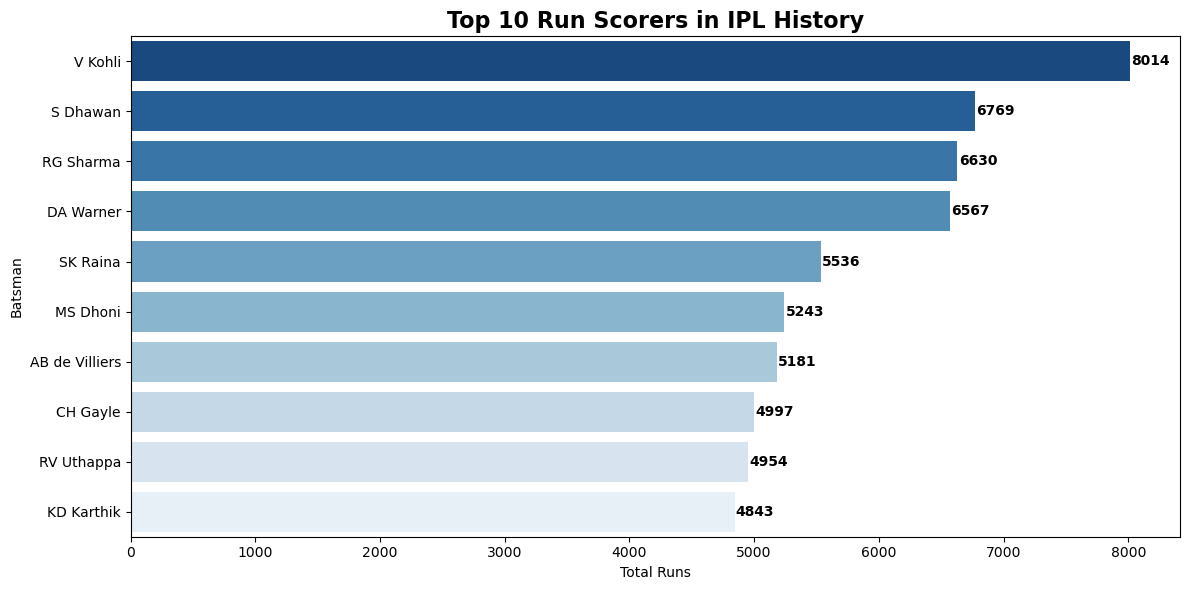

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


In [12]:
# Step 22: Top 10 run scorers in IPL history
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index,
            hue=top_batsmen.index, palette='Blues_r', legend=False)

plt.title('Top 10 Run Scorers in IPL History',
          fontsize=16, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')

for i, v in enumerate(top_batsmen.values):
    plt.text(v + 10, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\top_batsmen.png")
plt.show()

print(top_batsmen)

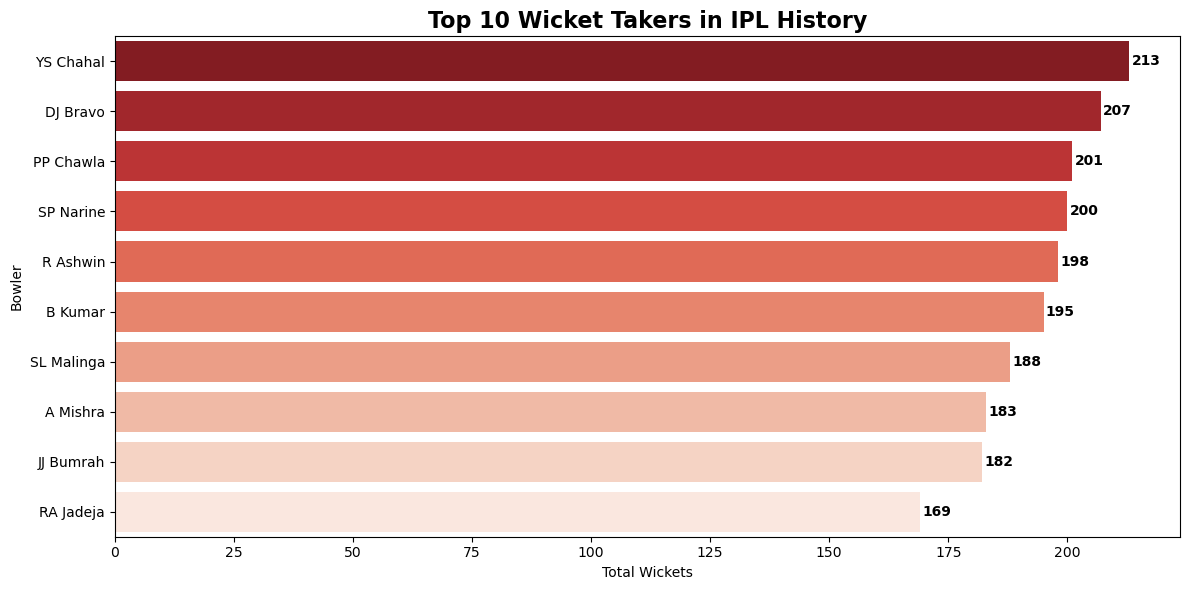

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64


In [13]:
# Step 23: Top 10 wicket takers in IPL history
wickets = deliveries[deliveries['is_wicket'] == 1]
top_bowlers = wickets.groupby('bowler')['is_wicket'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index,
            hue=top_bowlers.index, palette='Reds_r', legend=False)

plt.title('Top 10 Wicket Takers in IPL History',
          fontsize=16, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')

for i, v in enumerate(top_bowlers.values):
    plt.text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\top_bowlers.png")
plt.show()

print(top_bowlers)

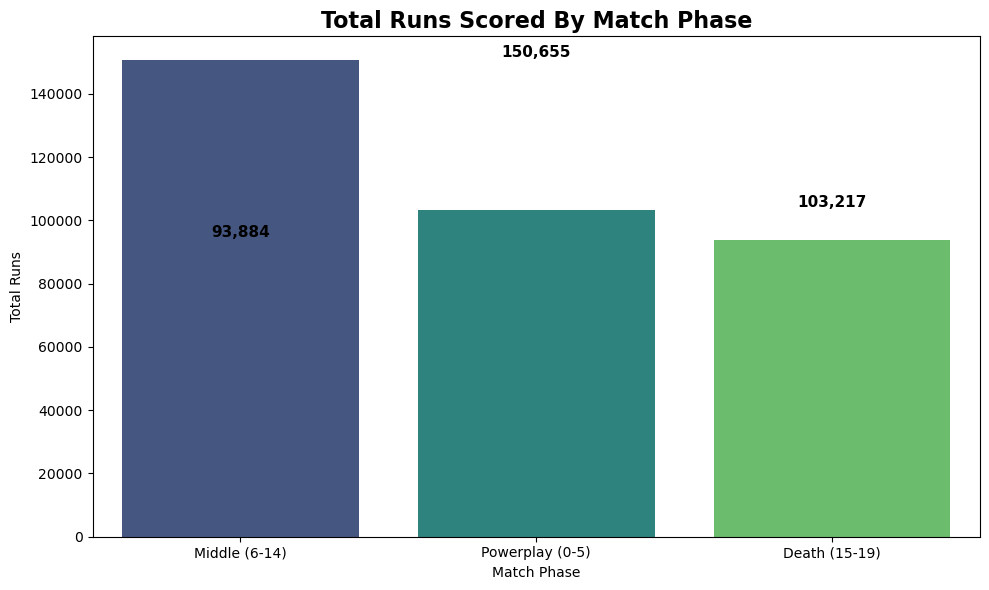

             phase  total_runs
1    Middle (6-14)      150655
2  Powerplay (0-5)      103217
0    Death (15-19)       93884


In [14]:
# Step 24: Runs scored by over phase
def get_phase(over):
    if over <= 5:
        return 'Powerplay (0-5)'
    elif over <= 14:
        return 'Middle (6-14)'
    else:
        return 'Death (15-19)'

deliveries['phase'] = deliveries['over'].apply(get_phase)

phase_runs = deliveries.groupby('phase')['total_runs'].sum().reset_index()
phase_runs = phase_runs.sort_values('total_runs', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=phase_runs, x='phase', y='total_runs',
            hue='phase', palette='viridis', legend=False)

plt.title('Total Runs Scored By Match Phase',
          fontsize=16, fontweight='bold')
plt.xlabel('Match Phase')
plt.ylabel('Total Runs')

for i, row in phase_runs.iterrows():
    plt.text(i, row['total_runs'] + 1000, f"{row['total_runs']:,}",
             ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\phase_runs.png")
plt.show()

print(phase_runs)

📊 BATTING ROLE ANALYSIS
            role  avg_strike_rate  avg_runs_per_innings  avg_balls_per_innings  player_count
        Finisher           128.27                 16.05                  12.34            38
    Middle Order           127.97                 24.46                  19.11            41
Opener/Top Order           125.69                 31.10                  24.72            22


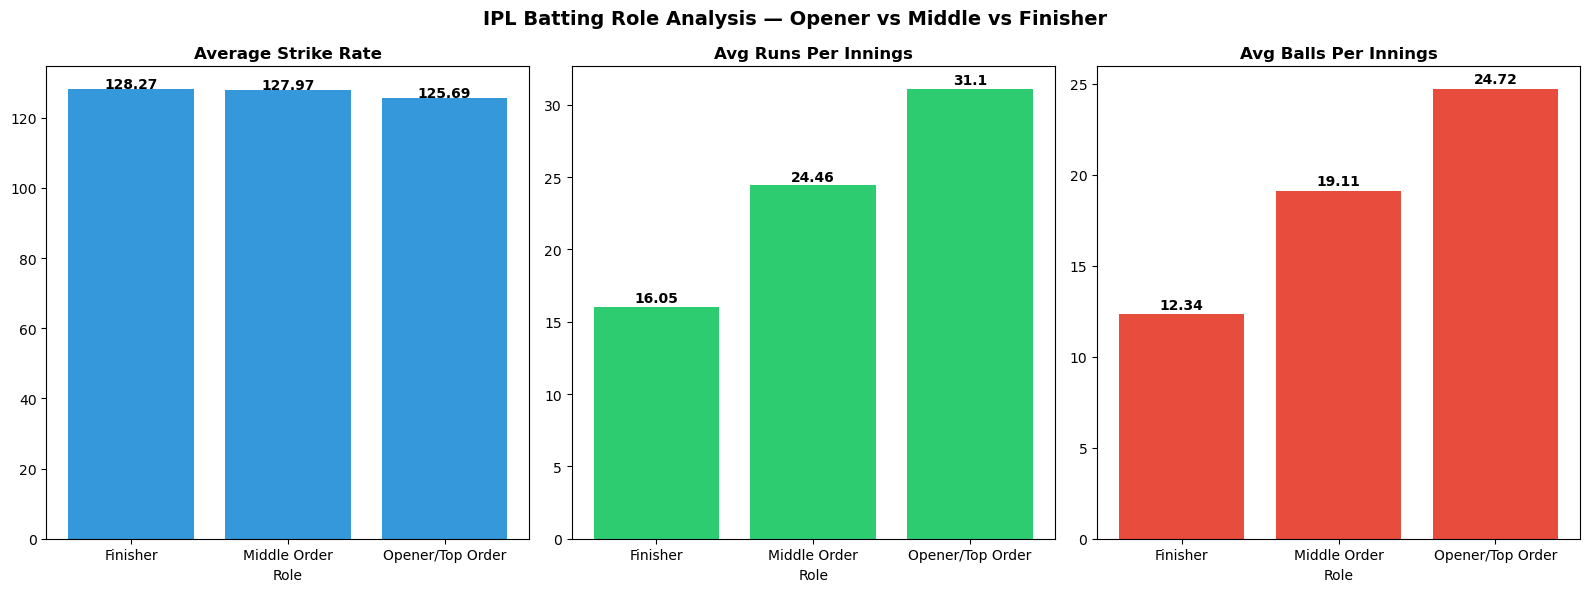

In [15]:
# Step 48: Opener vs Finisher Analysis
# Role classification
def classify_role(strike_rate, avg_balls):
    if avg_balls >= 22:
        return 'Opener/Top Order'
    elif avg_balls >= 16:
        return 'Middle Order'
    else:
        return 'Finisher'

# Get batting stats
batting_pos = deliveries.groupby(['match_id', 'batter']).agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()

batsman_stats = batting_pos.groupby('batter').agg(
    total_runs=('total_runs', 'sum'),
    total_balls=('balls_faced', 'sum'),
    innings=('match_id', 'count')
).reset_index()

# Filter minimum 50 innings for reliability
batsman_stats = batsman_stats[batsman_stats['innings'] >= 50]

batsman_stats['strike_rate'] = (batsman_stats['total_runs'] / 
                                 batsman_stats['total_balls'] * 100).round(2)
batsman_stats['avg_runs_per_innings'] = (batsman_stats['total_runs'] / 
                                          batsman_stats['innings']).round(2)
batsman_stats['avg_balls_per_innings'] = (batsman_stats['total_balls'] / 
                                           batsman_stats['innings']).round(2)
batsman_stats['role'] = batsman_stats.apply(
    lambda x: classify_role(x['strike_rate'], 
                             x['avg_balls_per_innings']), axis=1)

# Role wise average stats
role_summary = batsman_stats.groupby('role').agg(
    avg_strike_rate=('strike_rate', 'mean'),
    avg_runs_per_innings=('avg_runs_per_innings', 'mean'),
    avg_balls_per_innings=('avg_balls_per_innings', 'mean'),
    player_count=('batter', 'count')
).round(2).reset_index()

print("📊 BATTING ROLE ANALYSIS")
print("="*70)
print(role_summary.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16,6))
fig.suptitle('IPL Batting Role Analysis — Opener vs Middle vs Finisher',
             fontsize=14, fontweight='bold')

metrics = ['avg_strike_rate', 'avg_runs_per_innings', 'avg_balls_per_innings']
titles = ['Average Strike Rate', 'Avg Runs Per Innings', 'Avg Balls Per Innings']
colors = ['#3498DB', '#2ECC71', '#E74C3C']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    axes[i].bar(role_summary['role'], role_summary[metric], color=color)
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('Role')
    for j, v in enumerate(role_summary[metric]):
        axes[i].text(j, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\Shruti Kumari Pandey\Desktop\My Data Analysis Projects\CricketPulse-AI\reports\batting_role_analysis.png")
plt.show()

In [ ]:
power